# QSVT Introduction

**Quantum Singular Value Transformation (QSVT)** applies bounded polynomials
to block-encoded signals through the public `qsvt-pennylane` package API.

The examples cover:

1. **QSVT on a scalar** — treating a real number $a$ as a block-encoded
   operator and applying a polynomial transform.
2. **QSVT on a diagonal matrix** — showing how QSVT transforms each diagonal
   entry independently.

Both examples use the polynomial

$$f(x) = x^2.$$

This is a natural first example because it is simple, bounded on $[-1,1]$,
and easy to compare against the exact classical result.

## Variable definitions

- $a$ is the real scalar supplied to the block encoding.
- $x\in[-1,1]$ is a generic scalar signal value, and $f$ is the target polynomial.
- $c_k$ is the coefficient of $x^k$ for $k\in\{0,1,2\}$; `coeffs` stores them in ascending $k$.
- $A$ is the $n$-dimensional diagonal Hermitian matrix, and $\lambda_i$ is its $i$th eigenvalue for $i\in\{1,\ldots,n\}$.

## Notebook guide

- **Learning objective:** apply and validate scalar and diagonal polynomial transforms.
- **Prerequisites:** an editable repository install plus basic NumPy and linear-algebra familiarity.
- **Estimated runtime:** about 1–3 minutes on a local CPU.
- **Navigation:** [collection index](README.md) · [next](02_QSVT_Singular_Value_Filter.ipynb).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qsvt.polynomials import eval_polynomial
from qsvt.qsvt import (
    classical_diagonal_polynomial_transform,
    qsvt_diagonal_transform,
    qsvt_scalar_output,
    qsvt_scalar_scan,
)

## Target polynomial

The target polynomial

$$f(x) = x^2$$

in standard coefficient form with coefficients ordered by ascending degree:

$$f(x) = c_0 + c_1 x + c_2 x^2,$$

so the coefficient array is:

`coeffs = [0, 0, 1]`

In [2]:
coeffs = np.array([0.0, 0.0, 1.0])

Sample-point evaluation confirms the polynomial values.

In [3]:
x_demo = np.array([-1.0, -0.5, 0.0, 0.5, 1.0])
y_demo = eval_polynomial(coeffs, x_demo)

print("coeffs =", coeffs)
print("x_demo =", x_demo)
print("f(x_demo) =", y_demo)

coeffs = [0. 0. 1.]
x_demo = [-1.  -0.5  0.   0.5  1. ]
f(x_demo) = [1.   0.25 0.   0.25 1.  ]


## QSVT on a Scalar

The package helper `qsvt_scalar_output` applies the transform to a scalar input.

Conceptually:

- the scalar is treated as a small block-encoded object,
- QSVT applies the polynomial transform,
- the returned scalar is the transformed value.

A scan over $[-1,1]$ compares the QSVT output with the
exact classical curve $x^2$.

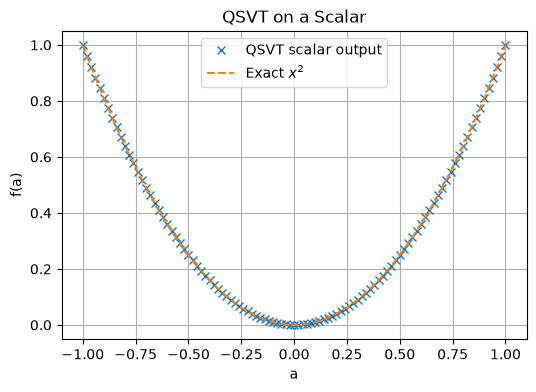

In [4]:
a_vals = np.linspace(-1.0, 1.0, 101)
qsvt_vals = qsvt_scalar_scan(a_vals, coeffs)
exact_vals = eval_polynomial(coeffs, a_vals)

plt.figure(figsize=(6, 4))
plt.plot(a_vals, qsvt_vals, "x", label="QSVT scalar output")
plt.plot(a_vals, exact_vals, "--", label="Exact $x^2$")
plt.xlabel("a")
plt.ylabel("f(a)")
plt.title("QSVT on a Scalar")
plt.legend()
plt.grid(True)
plt.show()

The QSVT-computed values should closely match the exact curve.

This is the smallest useful example of QSVT: a single scalar behaves like a
single singular value, and the polynomial transform acts directly on it.

A direct scalar evaluation provides a compact spot check.

In [5]:
a0 = 0.6
qsvt_a0 = qsvt_scalar_output(a0, coeffs)
exact_a0 = eval_polynomial(coeffs, a0)

print(f"a0 = {a0}")
print(f"QSVT output = {qsvt_a0}")
print(f"Exact f(a0) = {exact_a0}")
print(f"Absolute error = {abs(qsvt_a0 - exact_a0):.3e}")

a0 = 0.6
QSVT output = 0.3599999999996402
Exact f(a0) = 0.36
Absolute error = 3.598e-13


## QSVT on a Diagonal Matrix

Consider the diagonal matrix

$$A = \mathrm{diag}(\lambda_1, \lambda_2, \dots, \lambda_n).$$

For a diagonal matrix, QSVT acts entrywise on the diagonal values in this
simple setting, giving the expected map

$$\lambda_i \mapsto f(\lambda_i) = \lambda_i^2.$$

The comparison includes:

- the QSVT-based diagonal transform, and
- the exact classical diagonal polynomial transform.

Matrix examples pass explicit wires.

A diagonal with 16 entries corresponds to a 16 x 16 operator requiring 4 data qubits. Embedding-based block encoding adds one ancilla, for 5 wires total.

Passing wires explicitly keeps the notebook behaviour clear and avoids hidden assumptions about inferred register sizes.

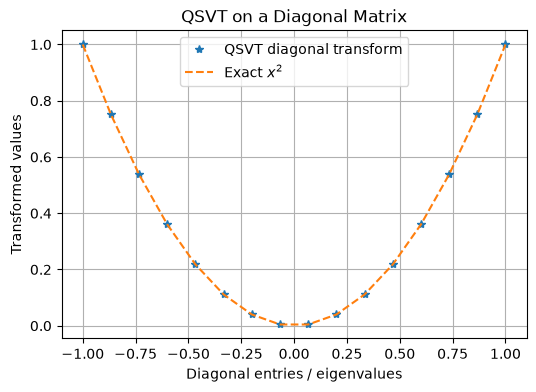

In [6]:
eigvals = np.linspace(-1.0, 1.0, 16)

# A 16x16 matrix needs 4 data qubits.
# Embedding-based block encoding requires one additional ancilla qubit,
# so the call explicitly provides 5 wires total.
encoding_wires = list(range(5))
wire_order = list(range(5))

qsvt_diag = qsvt_diagonal_transform(
    eigvals,
    coeffs,
    encoding_wires=encoding_wires,
    wire_order=wire_order,
)
exact_diag = classical_diagonal_polynomial_transform(eigvals, coeffs)

plt.figure(figsize=(6, 4))
plt.plot(eigvals, qsvt_diag, "*", label="QSVT diagonal transform")
plt.plot(eigvals, exact_diag, "--", label="Exact $x^2$")
plt.xlabel("Diagonal entries / eigenvalues")
plt.ylabel("Transformed values")
plt.title("QSVT on a Diagonal Matrix")
plt.legend()
plt.grid(True)
plt.show()

The transformed diagonal entries should agree closely with the exact
polynomial values.

This illustrates the core idea behind QSVT:

> a polynomial is applied to singular values (or, in this diagonal Hermitian
> setting, eigenvalues) through a block-encoded quantum transformation.

Subsequent tutorials extend $x^2$ to more useful families:

- singular-value filters,
- sign-like transforms,
- inverse-like transforms,
- polynomial approximations to matrix functions.

## Validation

Compact checks for the expected tutorial behavior.


In [7]:
assert np.allclose(y_demo, x_demo**2)
assert np.allclose(qsvt_vals, exact_vals, atol=1e-9)
assert abs(qsvt_a0 - exact_a0) < 1e-9
assert np.allclose(qsvt_diag, exact_diag, atol=1e-9)

print(f"scalar_abs_error: {abs(qsvt_a0 - exact_a0):.3e}")
print(f"diagonal_max_error: {np.max(np.abs(qsvt_diag - exact_diag)):.3e}")
print("validation: passed")

scalar_abs_error: 3.598e-13
diagonal_max_error: 1.000e-12
validation: passed


## Takeaways and next steps

- **Result:** The workflow shows how to apply and validate scalar and diagonal polynomial transforms.
- **Interpretation boundary:** Treat simulator-scale circuits and resource proxies according to the truth contract stated in the notebook.
- **Continue:** [collection index](README.md) · [next](02_QSVT_Singular_Value_Filter.ipynb).
